<a href="https://colab.research.google.com/github/kangtayie/Machine-Learning_class/blob/main/diabetes_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 당뇨병 데이터로 BMI 예측 회귀

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
# 데이터 불러오기
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/diabetes.csv")

In [3]:
# Outcome(옛 분류 레이블) 제거 → BMI를 새 레이블로
df_reg = df.drop("Outcome", axis=1)

In [4]:
# 레이블 제거 확인
df_reg

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [5]:
# BMI 빼고 나머지가 입력
X = df_reg.drop("BMI", axis=1)
# BMI가 예측 대상
y = df_reg["BMI"]

In [7]:
#입력데이터 확인
X

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,0.627,50
1,1,85,66,29,0,0.351,31
2,8,183,64,0,0,0.672,32
3,1,89,66,23,94,0.167,21
4,0,137,40,35,168,2.288,33
...,...,...,...,...,...,...,...
763,10,101,76,48,180,0.171,63
764,2,122,70,27,0,0.340,27
765,5,121,72,23,112,0.245,30
766,1,126,60,0,0,0.349,47


In [8]:
#정답 확인
y

,BMI
0,33.6
1,26.6
2,23.3
3,28.1
4,43.1
...,...
763,32.9
764,36.8
765,26.2
766,30.1


In [9]:
# 훈련/테스트 분리 (회귀는 stratify 안 씀 — y가 연속값이라)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
# 모델 생성 → 훈련 → 예측 → 평가
reg_models = {
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42),
    "Linear": LinearRegression(),
}

for name, model in reg_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f"--- {name} ---")
    print(f"MAE={mae:.2f}  RMSE={rmse:.2f}  R2={r2:.3f}\n")

--- DecisionTree ---
MAE=7.25  RMSE=10.20  R2=-0.465

--- RandomForest ---
MAE=5.21  RMSE=6.91  R2=0.329

--- Linear ---
MAE=5.21  RMSE=7.23  R2=0.265



# 정답값(BMI) 분포 시각화

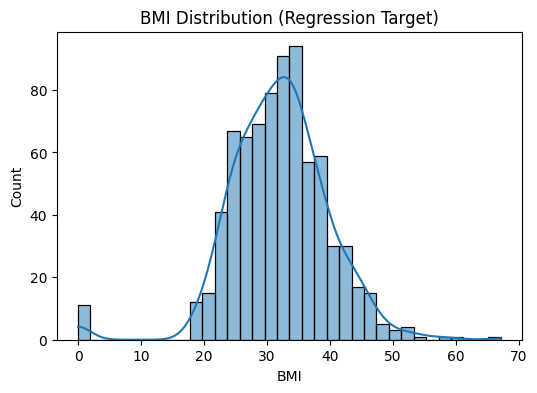

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.histplot(y, kde=True)          # y = df_reg["BMI"]
plt.title("BMI Distribution (Regression Target)")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.show()

# 예측값 vs 실제값 시각화

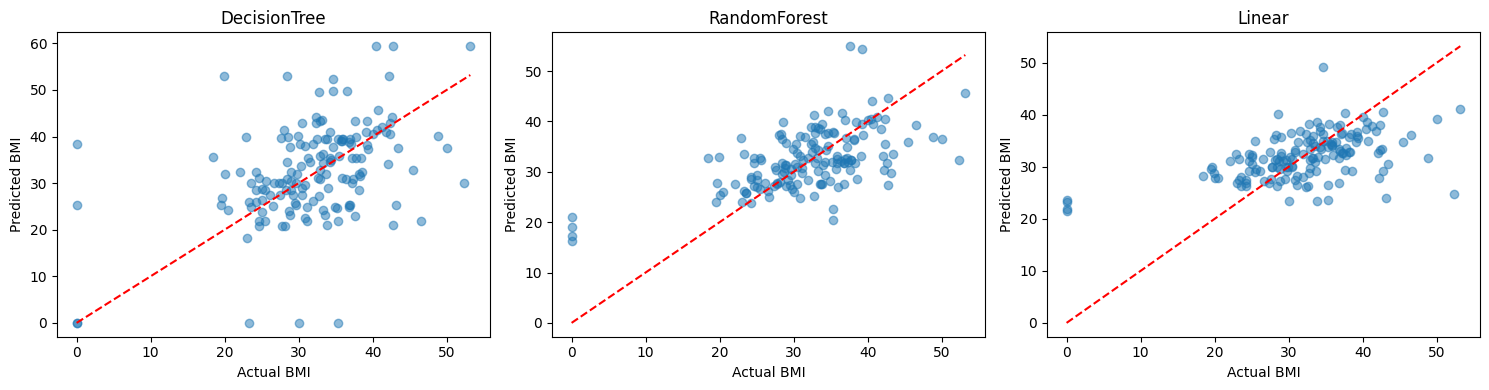

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, reg_models.items()):
    pred = model.predict(X_test)
    ax.scatter(y_test, pred, alpha=0.5)
    lims = [y_test.min(), y_test.max()]
    ax.plot(lims, lims, "r--")     # 완벽 예측선 (y=x)
    ax.set_xlabel("Actual BMI")
    ax.set_ylabel("Predicted BMI")
    ax.set_title(name)
plt.tight_layout()
plt.show()